In [14]:
import sympy as sp
import numpy as np
import dg_geometry as DG503

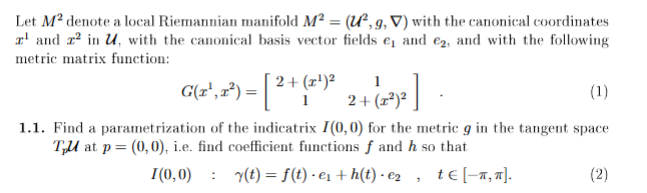

In [42]:
x1, x2, t = sp.symbols('x1 x2 t', real=True)

G  = sp.Matrix([[2 + x1**2, 1], [1, 2 + x2**2]])
display(G)

f = sp.Function('f')(t)
h = sp.Function('h')(t)

G_0 = G.subs({x1: 0, x2: 0 })

V = sp.Matrix([f, h])

I = DG503.g_dot(G_0, V, V)
display(I)

ev_data = G_0.eigenvects()

lam1, _, [v1_raw] = ev_data[0] # lambda = 1
lam2, _, [v2_raw] = ev_data[1] # lambda = 3

v1 = sp.simplify(v1_raw / v1_raw.norm())
v2 = sp.simplify(v2_raw / v2_raw.norm())

w1 = v1 / sp.sqrt(lam1)
w2 = v2 / sp.sqrt(lam2)

V = sp.cos(t) * w1 + sp.sin(t) * w2

display(V)

I = DG503.g_dot(G_0, V, V)
display(I)


Matrix([
[x1**2 + 2,         1],
[        1, x2**2 + 2]])

2*f(t)**2 + 2*f(t)*h(t) + 2*h(t)**2

Matrix([
[sqrt(6)*sin(t)/6 - sqrt(2)*cos(t)/2],
[sqrt(6)*sin(t)/6 + sqrt(2)*cos(t)/2]])

1

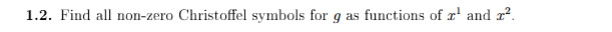

In [44]:
chris = DG503.christoffel_symbols(G, [x1, x2])
display(chris)
display(chris[0,0,0])
display(chris[0,0,1])
display(chris[1,1,0])
display(chris[1,1,1])

{(0, 0, 0): x1*(x2**2 + 2)/(x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 3),
 (0, 0, 1): -x1/(x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 3),
 (0, 1, 0): 0,
 (0, 1, 1): 0,
 (1, 0, 0): 0,
 (1, 0, 1): 0,
 (1, 1, 0): -x2/(x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 3),
 (1, 1, 1): x2*(x1**2 + 2)/(x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 3)}

x1*(x2**2 + 2)/(x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 3)

-x1/(x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 3)

-x2/(x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 3)

x2*(x1**2 + 2)/(x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 3)

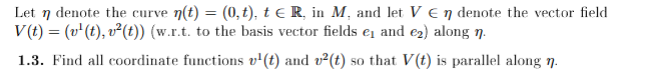

In [46]:
v1 = sp.Function('v1')(t)
v2 = sp.Function('v2')(t)
V = sp.Matrix([v1, v2])
coords = [x1, x2]

eta = sp.Matrix([0, t])

cov_gamma = DG503.covariant_derivative_along_curve(G, eta,V, t, coords)
display(cov_gamma)

# Define the system of equations (Matrix == 0)
system = [sp.Eq(cov_gamma[0], 0), sp.Eq(cov_gamma[1], 0)]

# Define the functions to solve for
funcs = [v2, v1]

# Solve the system
sol = sp.dsolve(system, funcs)

# Display the result
for s_eq in sol:
    display(sp.simplify(s_eq))

Matrix([
[ (-t*v2(t) + (2*t**2 + 3)*Derivative(v1(t), t))/(2*t**2 + 3)],
[(2*t*v2(t) + (2*t**2 + 3)*Derivative(v2(t), t))/(2*t**2 + 3)]])

Eq(v2(t), C1/sqrt(2*t**2 + 3))

Eq(v1(t), C1/2 - C1/(2*sqrt(2*t**2 + 3)) + C2)

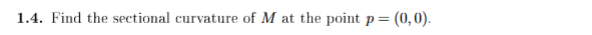

In [48]:
sec_curv = DG503.sectional_curvature(G, sp.Matrix([x1,x2]), sp.Matrix([1, 0]), sp.Matrix([0, 1]), coords)

display(sec_curv.subs({x1: 0, x2: 0}))

0

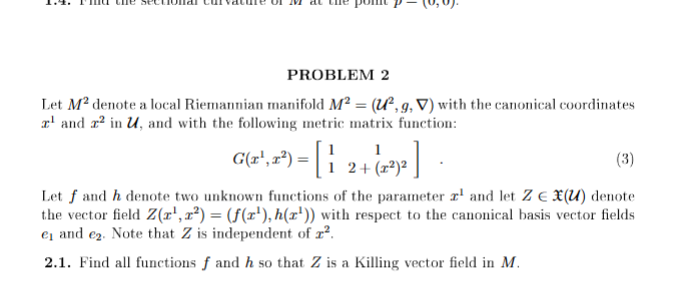

In [54]:
x1, x2 = sp.symbols('x1 x2', real=True)

f = sp.Function('f')(x1)
h = sp.Function('h')(x1)

G = sp.Matrix([[1, 1], [1, 2+ x2**2]])

Z = sp.Matrix([f, h])

Lv_g = DG503.lie_derivative_metric(G, Z, coords)
display(Lv_g),

# h has to be 0
Lv_g = sp.simplify(Lv_g.subs({h: 0}))
display(Lv_g)

# And then f has to be a constant
c = sp.symbols('c', real=True)
Lv_g = sp.simplify(Lv_g.subs({f: c}))
display(Lv_g)

Matrix([
[        2*Derivative(f(x1), x1) + 2*Derivative(h(x1), x1), (x2**2 + 2)*Derivative(h(x1), x1) + Derivative(f(x1), x1)],
[(x2**2 + 2)*Derivative(h(x1), x1) + Derivative(f(x1), x1),                                                2*x2*h(x1)]])

Matrix([
[2*Derivative(f(x1), x1), Derivative(f(x1), x1)],
[  Derivative(f(x1), x1),                     0]])

Matrix([
[0, 0],
[0, 0]])

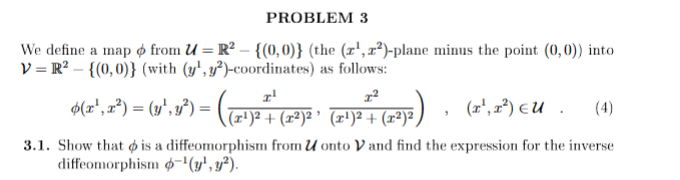

In [73]:
x1, x2, y1, y2 = sp.symbols('x1 x2 y1 y2', real=True)

phi = sp.Matrix([x1/(x1**2+x2**2), x2/(x1**2+x2**2)])
display(phi)


# If sol is the result of solve
sol = sp.solve([sp.Eq(phi[0], y1), sp.Eq(phi[1], y2)], (x1, x2))

phi_inv = sp.Matrix([sol[0][0], sol[0][1]])
display(phi_inv)

J = sp.simplify(phi.jacobian([x1, x2]).subs({x1: phi_inv[0], x2: phi_inv[1]}))
display(J)

det_J = J.det()
display(sp.simplify(det_J))

# Access the expressions using the symbols as keys
display(sol[0])


J_inv = phi_inv.jacobian([y1, y2])
display(J_inv)

det_J_inv = J_inv.det()
display(det_J_inv)

J_J_inv = J * J_inv
display(sp.simplify(J_J_inv))

phi_inv_phi = phi_inv.subs({y1: phi[0], y2: phi[1]})
display(sp.simplify(phi_inv_phi))


Matrix([
[x1/(x1**2 + x2**2)],
[x2/(x1**2 + x2**2)]])

Matrix([
[y1/(y1**2 + y2**2)],
[y2/(y1**2 + y2**2)]])

Matrix([
[-y1**2 + y2**2,      -2*y1*y2],
[      -2*y1*y2, y1**2 - y2**2]])

-y1**4 - 2*y1**2*y2**2 - y2**4

(y1/(y1**2 + y2**2), y2/(y1**2 + y2**2))

Matrix([
[-2*y1**2/(y1**2 + y2**2)**2 + 1/(y1**2 + y2**2),                     -2*y1*y2/(y1**2 + y2**2)**2],
[                    -2*y1*y2/(y1**2 + y2**2)**2, -2*y2**2/(y1**2 + y2**2)**2 + 1/(y1**2 + y2**2)]])

-1/(y1**4 + 2*y1**2*y2**2 + y2**4)

Matrix([
[1, 0],
[0, 1]])

Matrix([
[x1],
[x2]])

In [74]:
J_inv = phi_inv.jacobian([y1, y2])
display(sp.simplify(J_inv))

Matrix([
[(-y1**2 + y2**2)/(y1**4 + 2*y1**2*y2**2 + y2**4),                     -2*y1*y2/(y1**2 + y2**2)**2],
[                     -2*y1*y2/(y1**2 + y2**2)**2, (y1**2 - y2**2)/(y1**4 + 2*y1**2*y2**2 + y2**4)]])

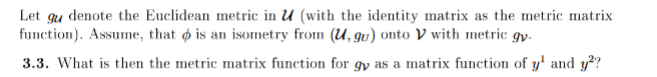

In [70]:
G_u = sp.eye(2)

G_v = sp.simplify(J_inv.T * G_u.subs({x1: phi_inv[0], x2: phi_inv[1]}) * J_inv)
display(G_v)

Matrix([
[1/(y1**4 + 2*y1**2*y2**2 + y2**4),                                 0],
[                                0, 1/(y1**4 + 2*y1**2*y2**2 + y2**4)]])

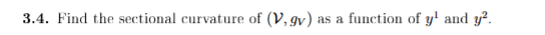

In [80]:
coords = [y1, y2]
a, b, c, d = sp.symbols('a b c d', real=True)

sec_curv = DG503.sectional_curvature(G_v, sp.Matrix([y1,y2]), sp.Matrix([a, b]), sp.Matrix([c, d]), coords)
display(sec_curv)

0

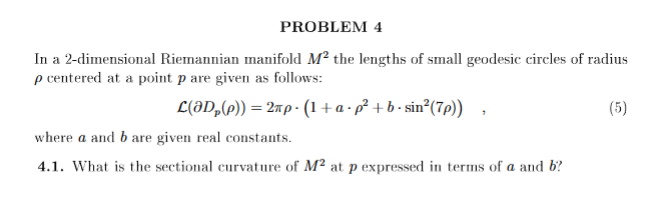

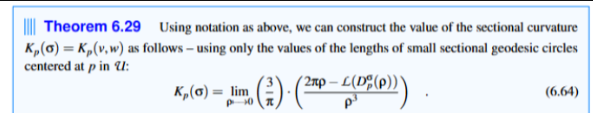

In [ ]:
rho, a, b = sp.symbols('rho a b', real=True)

L = 2* sp.pi * rho * (1 + a * rho**2 + b * sp.sin(7*rho)**2)

K_p = sp.limit(3/(sp.pi)*(2*sp.pi*rho-L)/(rho**3), rho, 0)

display(K_p)

3*(-2*pi*a - 98*pi*b)/pi

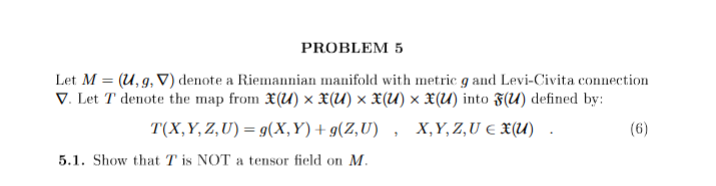

$T(X,Y,Z,U)=g(X,Y) + g(Z,U)$

$T(X,Y,f*Z,U)=g(X,Y) + g(f*Z,U)$

$T(X,Y,f*Z,U)=g(X,Y) + f * g(Z,U)$

So it is not linear